In [233]:
import glob, os
import ast
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from astropy.io import fits
from scipy.optimize import curve_fit
import data_manage_lib as dml

%matplotlib widget

In [ ]:
       
def get_chi2(data, model, error):
    chi2 = np.sum((data - model)**2 / error**2)
    return chi2

def cos4(alpha, thetaE=0, amp=1):
    return amp *(np.cos(np.radians(thetaE - alpha)))**4

def cos2cos2(alpha, delta_theta, amp=1, offset=0):
    return amp * np.cos(np.radians(alpha))**2 * (np.cos(np.radians(alpha + 90 - delta_theta))**2 + offset)


# Scans automatisés

Les fichiers sont nommés Scan_Date_Time.fits

In [257]:
#path_save = '/home/lmousset/Projets_Recherche/COSMOCal/Tests_IAS_2026/Data/CosmoCal_data/'
path_save = "C:\\Users\\Administrator\\Documents\\Scripts_Commande_VNA\\CosmoCal_data\\"

hdul = fits.open(path_save + "Scan_20260302_155445.fits")
header = hdul[0].header
header


SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    1 / number of array dimensions                     
NAXIS1  =                   60                                                  
EXTEND  =                    T                                                  
DATATYPE= 'Frequency samples in GHz'                                            
THETA_R =                    0                                                  
START_FR=       110000000000.0                                                  
STOP_FRQ=       170000000000.0                                                  
POINTS  =                   60                                                  
STATE_AV=                    T                                                  
COUNT_AV=                   10                                                  
IFBW    =                 10

In [258]:
# alpha_min = header['THETA_MI']
# alpha_max = header['THETA_MA']

alpha_min = header['ALPH_MI']
alpha_max = header['ALPH_MA']
step = header['STEP']
nfreq = header['POINTS']

alpha = np.arange(alpha_min, alpha_max + step, step)
print(alpha.shape)

# For the first scans, THETA_R is not in the header but it was set to 0.0 during the acquisition, so we can use that as default value
if dml.has_key(hdul, key='THETA_R'):
    thetaR = header['THETA_R']
else:
    thetaR = 0.0
print(thetaR)

(39,)
0


In [259]:
hdul.info()  # View structure
freq_samples = hdul[0].data *1e-9  # Access frequency samples
mag = hdul[1].data  # Access magnitude
phi = hdul[2].data  # Access phase

# mag = hdul[0].data  # Access magnitude
# phi = hdul[1].data  # Access phase

print(mag.shape)  # Check shape of magnitude data [(nstep, nS, points)]

mag_lin = 10**(mag/10)
print(freq_samples)

Filename: C:\Users\Administrator\Documents\Scripts_Commande_VNA\CosmoCal_data\Scan_20260302_155445.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      20   (60,)   float64   
  1  MAGNITUDE     1 ImageHDU        10   (60, 4, 39)   float64   
  2  PHASE         1 ImageHDU        10   (60, 4, 39)   float64   
(39, 4, 60)
[110.         111.01694915 112.03389831 113.05084746 114.06779661
 115.08474576 116.10169492 117.11864407 118.13559322 119.15254237
 120.16949153 121.18644068 122.20338983 123.22033898 124.23728814
 125.25423729 126.27118644 127.28813559 128.30508475 129.3220339
 130.33898305 131.3559322  132.37288136 133.38983051 134.40677966
 135.42372881 136.44067797 137.45762712 138.47457627 139.49152542
 140.50847458 141.52542373 142.54237288 143.55932203 144.57627119
 145.59322034 146.61016949 147.62711864 148.6440678  149.66101695
 150.6779661  151.69491525 152.71186441 153.72881356 154.74576271
 155.76271186 156.77966102 157.796

## Plot the data

### Plot en fonction de l'angle

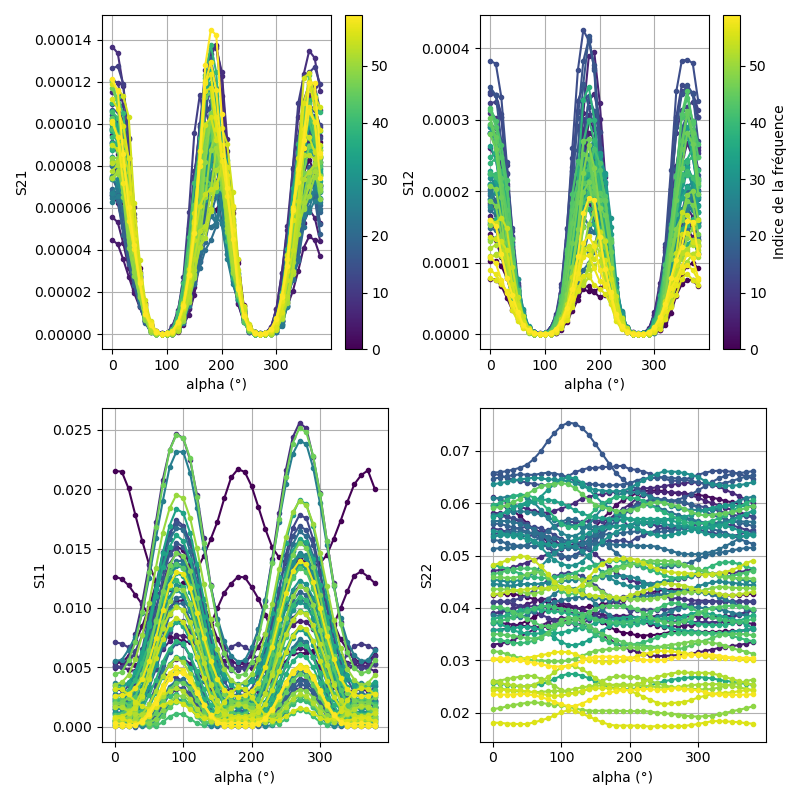

In [260]:
### Plot chaque fréquence

freqs = [0,2, 3, 10, 15, 20, 30, 40]
freqs = np.arange(60)
nf = len(freqs)
tt = np.arange(0, 380)
colors, norm, cmap = dml.get_colors(nf, cmap_name='viridis', vmin=0, vmax=nf-1)
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
ax = ax.ravel()
for i, f in enumerate(freqs):
    ax[0].plot(alpha, mag_lin[:, 0, f], '.-', color=colors[i]) # S21
    ax[1].plot(alpha, mag_lin[:, 1, f], '.-', color=colors[i]) # S12
    ax[2].plot(alpha, mag_lin[:, 2, f], '.-', color=colors[i]) # S11
    ax[3].plot(alpha, mag_lin[:, 3, f], '.-', color=colors[i]) # S22

ax[0].set_xlabel("alpha (°)")
ax[0].set_ylabel("S21")
#ax[0].set_yscale('log')
ax[0].grid(10)

ax[1].set_xlabel("alpha (°)")
ax[1].set_ylabel("S12")
#ax[1].set_yscale('log')
ax[1].grid(10)

ax[2].set_xlabel("alpha (°)")
ax[2].set_ylabel("S11")
#ax[2].set_yscale('log')
ax[2].grid(10)

ax[3].set_xlabel("alpha (°)")
ax[3].set_ylabel("S22")
#ax[3].set_yscale('log')
ax[3].grid(10)
# créer une colorbar qui montre l'échelle d'indices (ou de valeurs réelles)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # nécessaire pour colorbar
cbar = plt.colorbar(sm, ax=ax[0])
cbar = plt.colorbar(sm, ax=ax[1])
cbar.set_label('Indice de la fréquence')

fig.tight_layout()
#fig.savefig(f"../Plots/Scan_allfreqs.png", dpi=300)


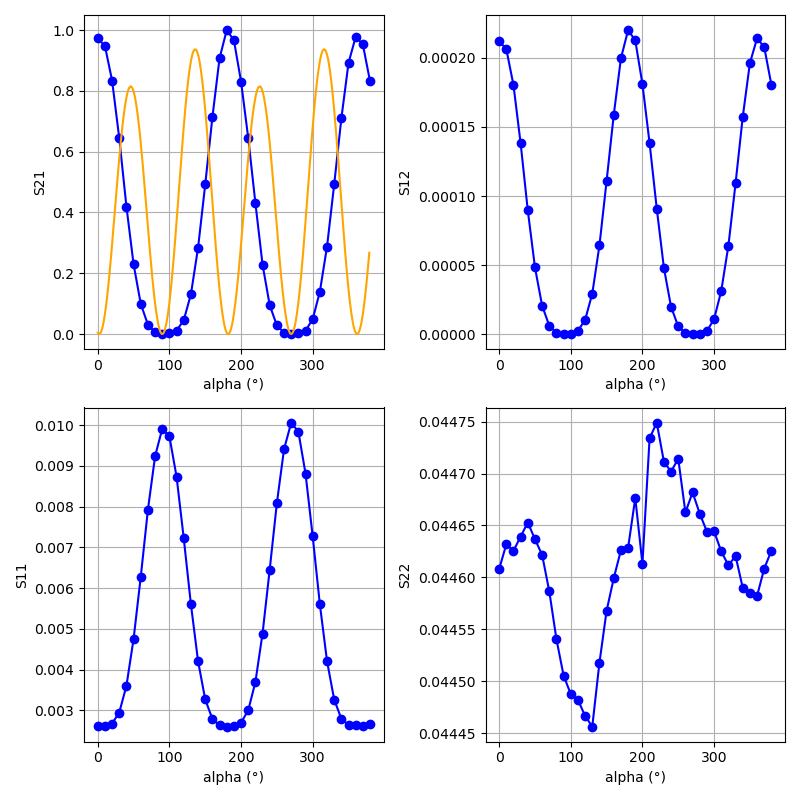

In [262]:
# Plot la moyenne sur les fréquences
tt = np.arange(0, 380)
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
ax = ax.ravel()

xx = np.arange(0, 380)
#plt.plot(xx, np.cos(np.radians(xx))**4, label=('cos^4'), color='red')



ax[0].plot(alpha, np.mean(mag_lin[:, 0, :], axis=1) / np.max( np.mean(mag_lin[:, 0, :], axis=1)), 'o-', color='b')
ax[0].plot(xx, np.cos(np.radians(xx))**2 * np.cos(np.radians(xx+88))**2*3.5, label=('cos^2*cos^2'), color='orange')
#ax[0].plot(tt, cos4(tt, 3), 'orange')
ax[0].set_xlabel("alpha (°)")
ax[0].set_ylabel("S21")
#ax[0].set_yscale('log')
ax[0].grid(10)

ax[1].plot(alpha, np.mean(mag_lin[:, 1, :], axis=1), 'o-', color= 'b')
#ax[1].plot(tt, cos4(tt, 3)*np.max(np.mean(mag_lin[:, 1, :], axis=1)), 'orange')
ax[1].set_xlabel("alpha (°)")
ax[1].set_ylabel("S12")
#ax[1].set_yscale('log')
ax[1].grid(10)

ax[2].plot(alpha, np.mean(mag_lin[:, 2, :], axis=1), 'o-', color= 'b')
ax[2].set_xlabel("alpha (°)")
ax[2].set_ylabel("S11")
#ax[2].set_yscale('log')
ax[2].grid(10)

ax[3].plot(alpha, np.mean(mag_lin[:, 3, :], axis=1), 'o-', color= 'b')
ax[3].set_xlabel("alpha (°)")
ax[3].set_ylabel("S22")
#ax[3].set_yscale('log')
ax[3].grid(10)

fig.tight_layout()





### Plot en fonction de la fréquence

In [253]:
ang = np.arange(39)
mag_lin_norm = np.zeros_like(mag_lin)
for i, a in enumerate(ang):
    mag_lin_norm[i, :, :] = mag_lin[a, :, :]/np.mean(mag_lin[a, :, :])
print(mag_lin_norm.shape)

(39, 4, 60)


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59]


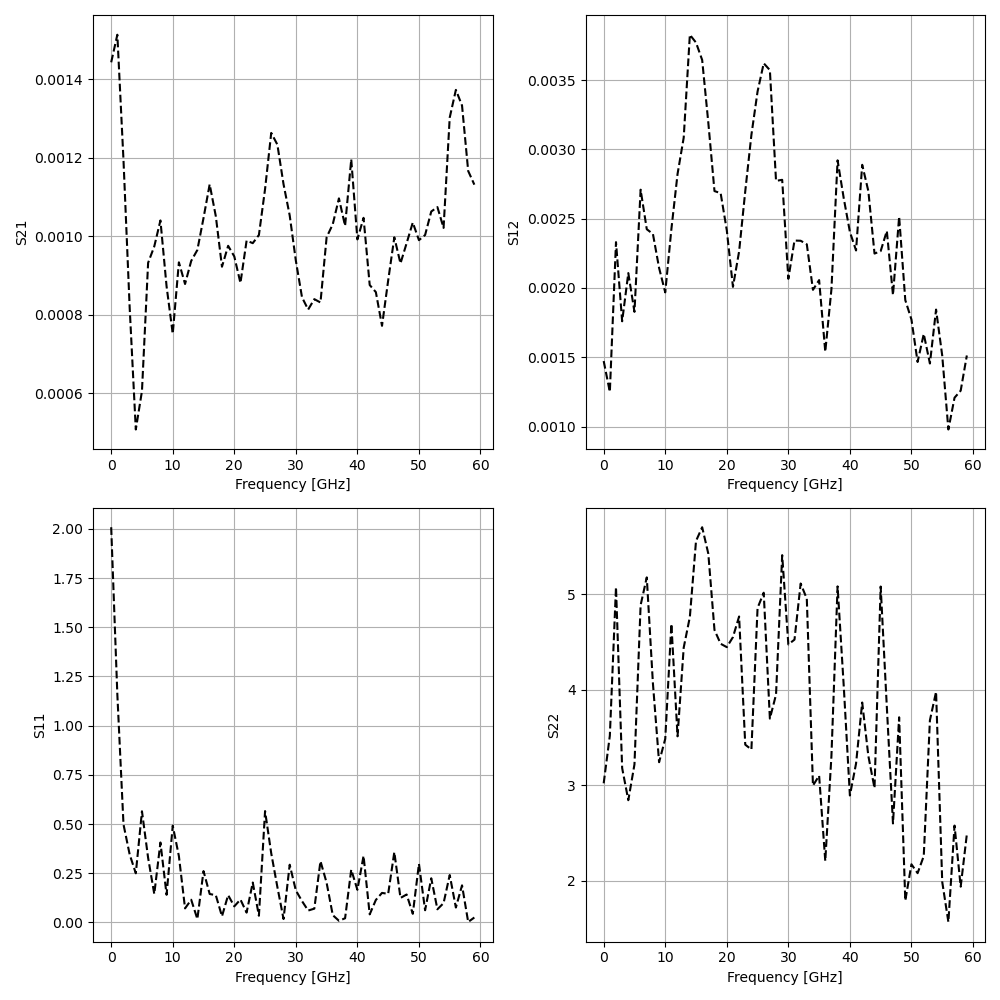

In [254]:
# Moyenne sur les angles
freqs = np.arange(0, 60)
print(freqs)
ang = [1] # indice de l'angle
ang = np.arange(39)
nf = len(ang)
tt = np.arange(0, 380)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.ravel()


ax[0].plot(np.mean(mag_lin_norm[:, 0, :], axis=0), color='black', linestyle='--')
ax[1].plot(np.mean(mag_lin_norm[:, 1, :], axis=0), color='black', linestyle='--')
ax[2].plot(np.mean(mag_lin_norm[:, 2, :], axis=0), color='black', linestyle='--')
ax[3].plot(np.mean(mag_lin_norm[:, 3, :], axis=0), color='black', linestyle='--')
# ax[1].plot(np.mean(mag_lin[:, 1, :], axis=0), color='black', linestyle='--')
# ax[1].axhline(np.mean(mag_lin[0, 1, :]), color='black', linestyle='--')

ax[0].set_xlabel("Frequency [GHz]")
ax[0].set_ylabel("S21")
#ax[0].set_yscale('log')
ax[0].grid(10)

ax[1].set_xlabel("Frequency [GHz]")
ax[1].set_ylabel("S12")
#ax[1].set_yscale('log')
ax[1].grid(10)


ax[2].set_xlabel("Frequency [GHz]")
ax[2].set_ylabel("S11")
#ax[2].set_yscale('log')
ax[2].grid(10)


ax[3].set_xlabel("Frequency [GHz]")
ax[3].set_ylabel("S22")
#ax[3].set_yscale('log')
ax[3].grid(10)


fig.tight_layout()

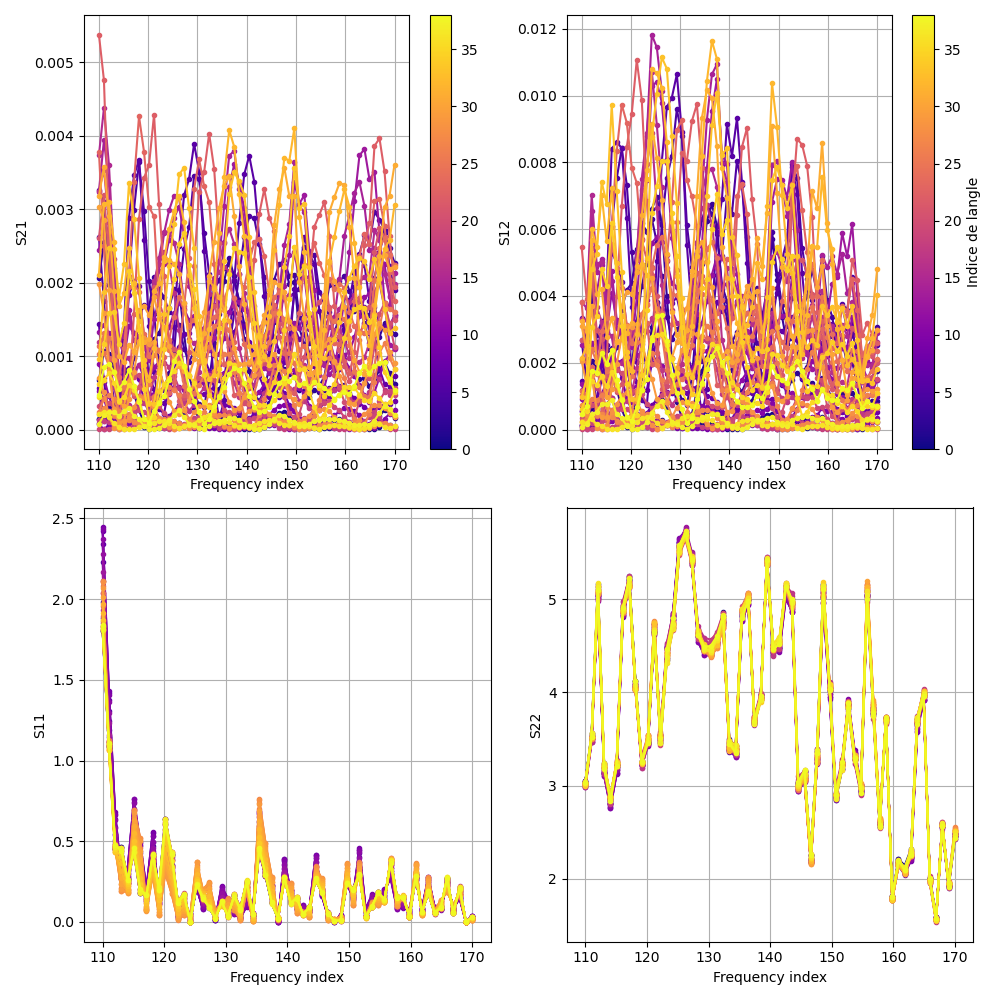

In [263]:
nang = 39
tt = np.arange(0, 380)
colors, norm, cmap = dml.get_colors(nang, cmap_name='plasma', vmin=0, vmax=nang-1)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.ravel()
for i, a in enumerate(np.arange(0, nang)):
    ax[0].plot(freq_samples, mag_lin_norm[a, 0, :], '.-', color=colors[i]) # S21
    ax[1].plot(freq_samples, mag_lin_norm[a, 1, :], '.-', color=colors[i]) # S12
    ax[2].plot(freq_samples, mag_lin_norm[a, 2, :], '.-', color=colors[i]) # S11
    ax[3].plot(freq_samples, mag_lin_norm[a, 3, :], '.-', color=colors[i]) # S22

ax[0].set_xlabel("Frequency index")
ax[0].set_ylabel("S21")
#ax[0].set_yscale('log')
ax[0].grid(10)

ax[1].set_xlabel("Frequency index")
ax[1].set_ylabel("S12")
#ax[1].set_yscale('log')
ax[1].grid(10)

ax[2].set_xlabel("Frequency index")
ax[2].set_ylabel("S11")
#ax[2].set_yscale('log')
ax[2].grid(10)

ax[3].set_xlabel("Frequency index")
ax[3].set_ylabel("S22")
#ax[3].set_yscale('log')
ax[3].grid(10)

#créer une colorbar qui montre l'échelle d'indices (ou de valeurs réelles)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # nécessaire pour colorbar
cbar = plt.colorbar(sm, ax=ax[0])
cbar = plt.colorbar(sm, ax=ax[1])
cbar.set_label('Indice de langle')

fig.tight_layout()

## Estimation d'une erreur

On a fait N=5 scans identiques sans rien changer. Cela va nous permettre d'estimer une erreur.

Notre tableau de données a 4 dimensions : [i, t, a, f]
avec
* i l'indice du scan, on a fait N=5 scans
* t l'indice du coeff de scattering (0 pour S21 et 1 pour S12)
* a pour l'angle alpha du polariseur, on a 39 positions entre 0 et 380°
* f pour la fréquence, on a 60 fréquences

Nous allons calculer le STD sur les N scans.

In [18]:
# Get the data
mag = []

os.chdir(path_save)

i = 0
for file in glob.glob("Scan_20260220_*.fits"):
    print(file)
    hdul = fits.open(path_save + file)
    header = hdul[0].header
    if has_key(hdul, key='THETA_R'):
        thetaR = header['THETA_R']
    else:
        thetaR = 0.0
    if thetaR == 0.0: # Get only the scan with THETA_R=0
        print(i, file)
        mag.append(hdul[0].data)  # Access magnitude
    i+=1

mag = np.array(mag)
print(mag.shape)

mag_lin = 10**(mag / 10)

nscans, nstep, nS, nfreq = mag_lin.shape

Scan_20260220_152013.fits
0 Scan_20260220_152013.fits
Scan_20260220_154834.fits
1 Scan_20260220_154834.fits
Scan_20260220_162014.fits
2 Scan_20260220_162014.fits
Scan_20260220_164558.fits
3 Scan_20260220_164558.fits
Scan_20260220_171128.fits
4 Scan_20260220_171128.fits
Scan_20260220_173700.fits
(5, 39, 4, 60)


In [19]:
mean_over_scans = np.mean(mag_lin, axis=0)
std_over_scans = np.std(mag_lin, axis=0)
print(std_over_scans.shape)

(39, 4, 60)


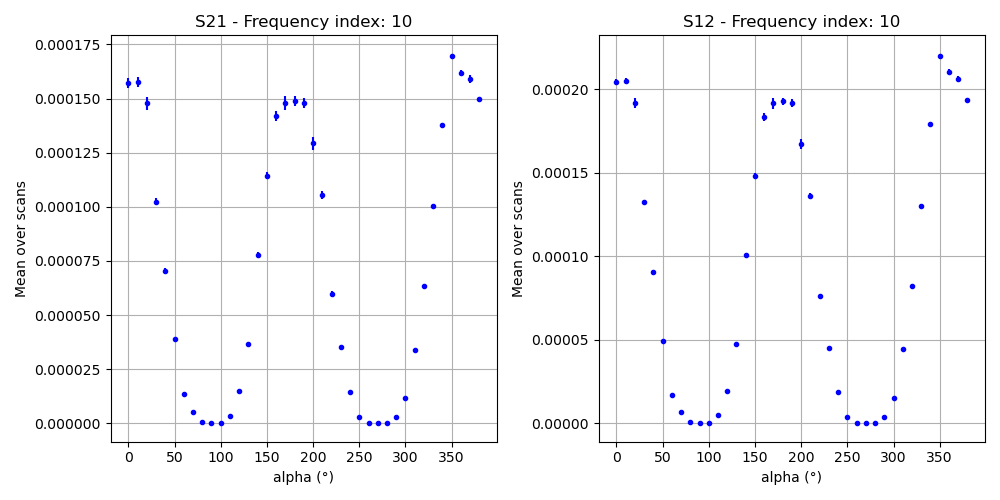

In [20]:
f = 10

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax = ax.ravel()

### S21
ax[0].errorbar(alpha, mean_over_scans[:, 0, f], yerr=std_over_scans[:, 0, f], color='b', ls='None', marker='.')
ax[0].set_xlabel("alpha (°)")
ax[0].set_ylabel("Mean over scans")
ax[0].set_title(f"S21 - Frequency index: {f}")
#ax[0].set_yscale('log')
ax[0].grid(10)

### S12
ax[1].errorbar(alpha, mean_over_scans[:, 1, f], yerr=std_over_scans[:, 1, f], color='b', ls='None', marker='.')
ax[1].set_xlabel("alpha (°)")
ax[1].set_ylabel("Mean over scans")
ax[1].set_title(f"S12 - Frequency index: {f}")
#ax[1].set_yscale('log')
ax[1].grid(10)

fig.tight_layout()
#fig.savefig(f"../Plots/Scan_MEAN_over_scans.png", dpi=300)


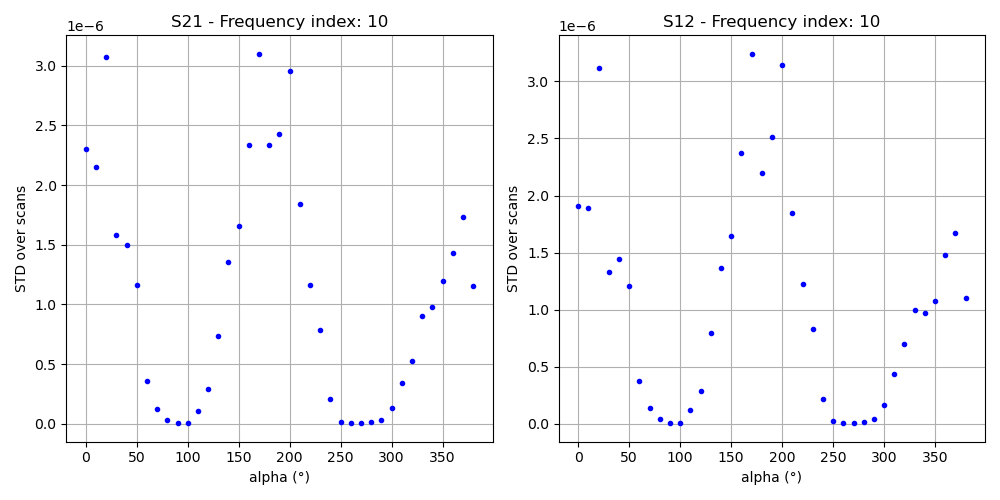

In [21]:
f = 10

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax = ax.ravel()

### S21
ax[0].plot(alpha, std_over_scans[:, 0, f], '.', color='b')
ax[0].set_xlabel("alpha (°)")
ax[0].set_ylabel("STD over scans")
ax[0].set_title(f"S21 - Frequency index: {f}")
#ax[0].set_yscale('log')
ax[0].grid(10)

### S12
ax[1].plot(alpha, std_over_scans[:, 1, f], '.', color='b')
ax[1].set_xlabel("alpha (°)")
ax[1].set_ylabel("STD over scans")
ax[1].set_title(f"S12 - Frequency index: {f}")
#ax[1].set_yscale('log')
ax[1].grid(10)

fig.tight_layout()
#fig.savefig(f"../Plots/Scan_STD_over_scans.png", dpi=300)

In [22]:
nscans

5

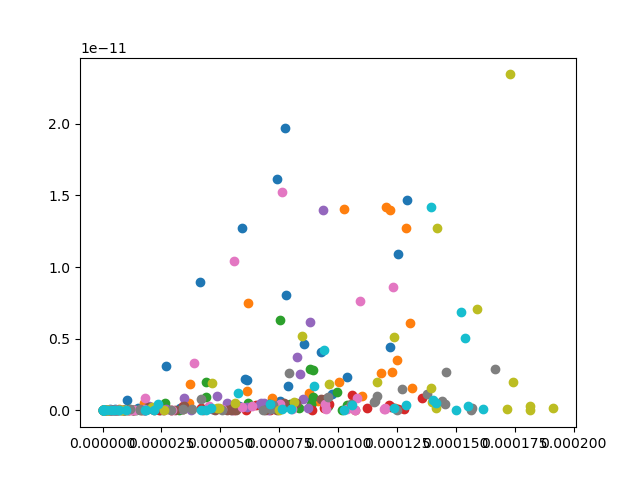

In [23]:
t = 0
plt.figure()
for f in range(10):
    plt.plot(mean_over_scans[:, t, f], std_over_scans[:, t, f]**2, 'o')

In [24]:
mean_over_freq = np.mean(mag_lin, axis=3)
std_over_freq = np.std(mag_lin, axis=3)
print(std_over_freq.shape)


(5, 39, 4)


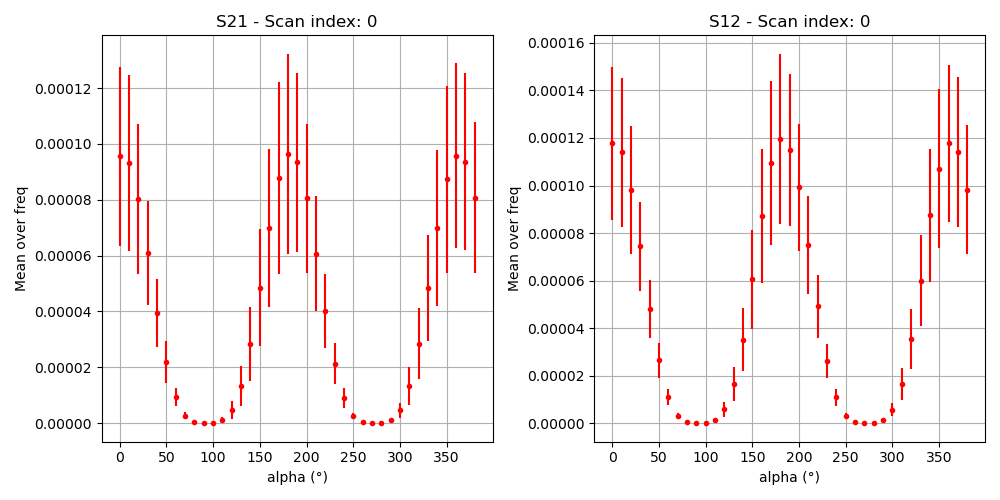

In [25]:
i = 0 # Scan

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax = ax.ravel()

### S21
ax[0].errorbar(alpha, mean_over_freq[i, :, 0], yerr=std_over_freq[i, :, 0], color='r', ls='None', marker='.')
ax[0].set_xlabel("alpha (°)")
ax[0].set_ylabel("Mean over freq")
ax[0].set_title(f"S21 - Scan index: {i}")
#ax[0].set_yscale('log')
ax[0].grid(10)

### S12
ax[1].errorbar(alpha, mean_over_freq[i, :, 1], yerr=std_over_freq[i, :, 0], color='r', ls='None', marker='.')
ax[1].set_xlabel("alpha (°)")
ax[1].set_ylabel("Mean over freq")
ax[1].set_title(f"S12 - Scan index: {i}")
#ax[1].set_yscale('log')
ax[1].grid(10)

fig.tight_layout()
#fig.savefig(f"../Plots/Scan_MEAN_over_freqs.png", dpi=300)

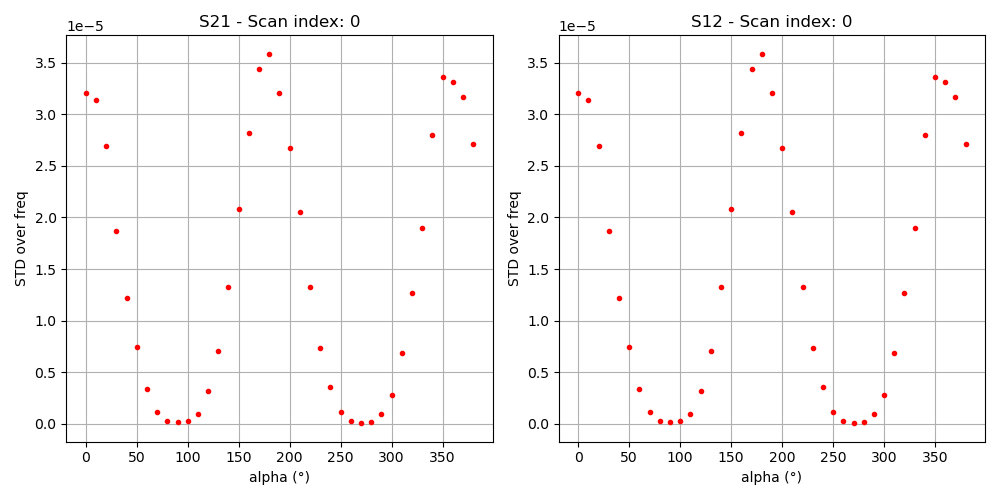

In [26]:
i = 0 # Scan

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax = ax.ravel()

### S21
ax[0].plot(alpha, std_over_freq[i, :, 0], color='r', ls='None', marker='.')
ax[0].set_xlabel("alpha (°)")
ax[0].set_ylabel("STD over freq")
ax[0].set_title(f"S21 - Scan index: {i}")
#ax[0].set_yscale('log')
ax[0].grid(10)

### S12
ax[1].plot(alpha, std_over_freq[i, :, 0], color='r', ls='None', marker='.')
ax[1].set_xlabel("alpha (°)")
ax[1].set_ylabel("STD over freq")
ax[1].set_title(f"S12 - Scan index: {i}")
#ax[1].set_yscale('log')
ax[1].grid(10)

fig.tight_layout()
#fig.savefig(f"../Plots/Scan_STD_over_freqs.png", dpi=300)

In [27]:
std_over_freq.shape

(5, 39, 4)

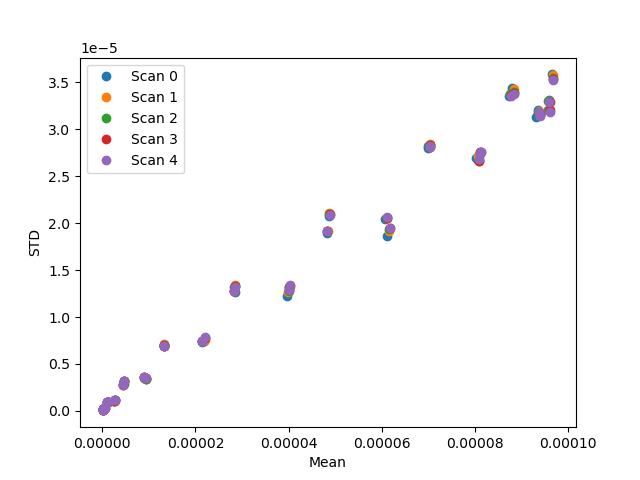

In [28]:
t = 0
fig = plt.figure()
for s in range(nscans):
    plt.plot(mean_over_freq[s, :, t], std_over_freq[s, :, t], 'o', label=f'Scan {s}')
plt.xlabel('Mean')
plt.ylabel('STD')
plt.legend()
#fig.savefig(f"../Plots/Scan_STDvsMEAN.png", dpi=300)


## Ajustement de la moyenne sur les scans par fréquence

On considère que les scans sont indépendants. Donc on peut diviser le STD par sqrt(N) pour avoir l'erreur sur la moyenne.

Paramètres optimisés : [2.02112091e+00 1.48354526e-04]
Erreurs sur les paramètres : [1.01161041e-02 6.53825356e-08]
Écart-type des résidus : 1.3430743560420784e-05
Chi2 : 88129.72247293316
Chi2 réduit : 2381.884391160356


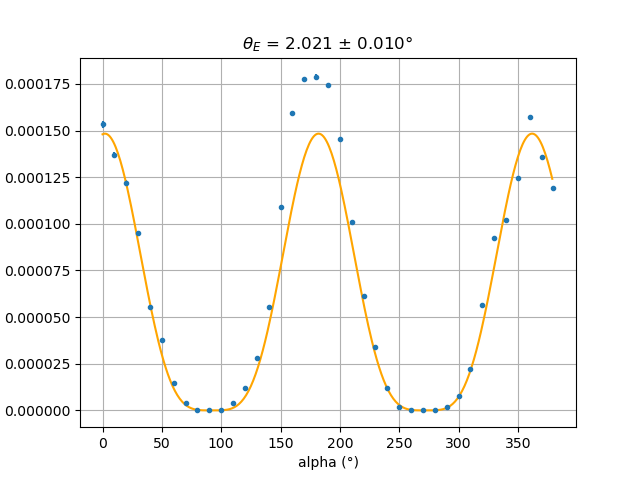

In [29]:
f = 12 # Frequency index 
t = 0 # trace index (S21 or S12)

signal = mean_over_scans[:, t, f]
sigma = std_over_scans[:, t, f] / np.sqrt(nscans)  # Erreur sur la moyenne

# Normalize to the max
#signal /= np.max(signal)

# Fit the data
popt, pcov = curve_fit(cos4, alpha, signal, sigma=sigma, absolute_sigma=True)
error = np.sqrt(np.diag(pcov))

print("Paramètres optimisés :", popt)
print("Erreurs sur les paramètres :", error)

# Residus et chi2
residuals = signal - cos4(alpha, *popt)
std_res = np.std(residuals)
print("Écart-type des résidus :", std_res)
chi2 = get_chi2(signal, cos4(alpha, *popt), sigma)
print("Chi2 :", chi2)

chi2_red = chi2 / (len(alpha) - len(popt))
print("Chi2 réduit :", chi2_red)

fig = plt.figure()
plt.errorbar(alpha, signal, yerr=sigma, marker='.', ls='None')
plt.plot(tt, cos4(tt, *popt), 'orange', label='Fit cos^4')
plt.xlabel("alpha (°)")
plt.ylabel("S21 mean over scans")
plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(popt[0], error[0]))
plt.grid(10)
#fig.savefig(f"../Plots/Scan_Fit_freq{f}.png", dpi=300)

In [30]:
# Loop over frequencies
t = 0 # trace index (S21 or S12)

allthetaE = []
allthetaE_err = []
allchi2_red = []

for f in range(60):
    signal = mean_over_scans[:, t, f]
    sigma = std_over_scans[:, t, f] / np.sqrt(nscans)  # Erreur sur la moyenne

    # Normalize to the max
    #signal /= np.max(signal)

    # Fit the data
    popt, pcov = curve_fit(cos4, alpha, signal, sigma=sigma, absolute_sigma=True)
    error = np.sqrt(np.diag(pcov))

    print("Paramètres optimisés :", popt)
    allthetaE.append(popt[0])
    print("Erreurs sur les paramètres :", error)
    allthetaE_err.append(error[0])

    # Residus et chi2
    residuals = signal - cos4(alpha, *popt)
    std_res = np.std(residuals)
    print("Écart-type des résidus :", std_res)
    chi2 = get_chi2(signal, cos4(alpha, *popt), sigma)
    print("Chi2 :", chi2)

    chi2_red = chi2 / (len(alpha) - len(popt))
    allchi2_red.append(chi2_red)
    print("Chi2 réduit :", chi2_red)

Paramètres optimisés : [-1.04538524e-01  1.01505374e-04]
Erreurs sur les paramètres : [2.10827396e-02 1.57946610e-07]
Écart-type des résidus : 1.3668911422165926e-05
Chi2 : 23868.495844631885
Chi2 réduit : 645.0944822873482
Paramètres optimisés : [5.37513379e+00 1.39674720e-04]
Erreurs sur les paramètres : [1.83336956e-02 1.24608199e-07]
Écart-type des résidus : 7.874474511504961e-06
Chi2 : 19393.63709972233
Chi2 réduit : 524.1523540465495
Paramètres optimisés : [2.72311990e+00 1.05842271e-04]
Erreurs sur les paramètres : [1.70145139e-02 6.55621532e-08]
Écart-type des résidus : 9.096509561082828e-06
Chi2 : 135489.98333499633
Chi2 réduit : 3661.8914414863875
Paramètres optimisés : [6.14693435e+00 1.15422733e-04]
Erreurs sur les paramètres : [8.74459622e-03 3.79803632e-08]
Écart-type des résidus : 7.635397445912438e-06
Chi2 : 147957.48269373795
Chi2 réduit : 3998.8508836145393
Paramètres optimisés : [4.50146592e+00 8.30741302e-05]
Erreurs sur les paramètres : [1.32719804e-02 4.36366779e-

In [31]:
np.array(np.round(allchi2_red))

array([ 645.,  524., 3662., 3999.,  548., 2191., 2841., 4247., 4297.,
       6603.,  703., 1023., 2382.,  812., 1117., 4942., 1163., 1053.,
       3572., 1329.,  883., 3163., 3372., 1867., 1617., 1922., 1321.,
       2541., 6715., 2230., 1653., 1150., 1085., 1341., 3003., 3390.,
       1040., 1370., 2765., 7356., 1188., 4259.,  988., 2294., 1622.,
        503., 1151.,  339.,  700., 1392.,  618.,  823.,  897.,  325.,
        554.,  778., 1661.,  438.,  909.,  601.])

0.002105409447887065
ThetaE moyen : 3.610916190013911
Écart-type de thetaE : 0.34674838268602987


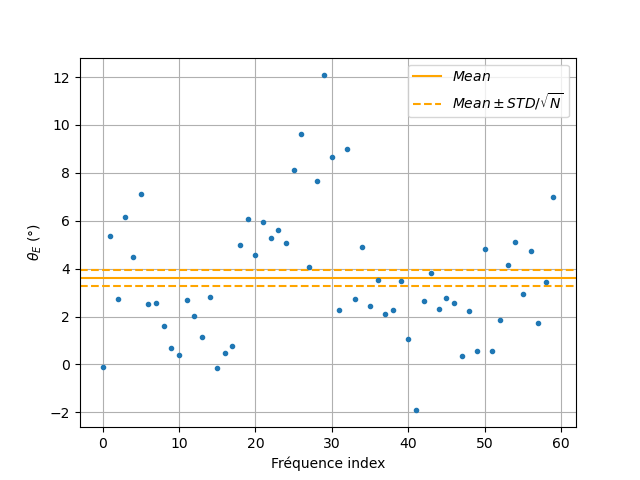

In [32]:
allthetaE = np.array(allthetaE)
allthetaE_err = np.array(allthetaE_err)

# Erreur sur la moyenne de thetaE
erreur = np.sqrt(np.sum(allthetaE_err**2 )) / nfreq
print(erreur)

mthetaE = np.mean(allthetaE)
print("ThetaE moyen :", mthetaE)
stdthetaE = np.std(allthetaE) / np.sqrt(nfreq)
print("Écart-type de thetaE :", stdthetaE)

fig = plt.figure()
plt.errorbar(np.arange(len(allthetaE)), allthetaE, yerr=allthetaE_err, fmt='.')
plt.axhline(mthetaE, color='orange', label=r'$Mean$')
plt.axhline(mthetaE-stdthetaE, color='orange', ls='--')
plt.axhline(mthetaE+stdthetaE, color='orange', label=r'$Mean \pm STD/\sqrt{N}$', ls='--')
plt.xlabel("Fréquence index")
plt.ylabel(r'$\theta_E$ (°)')
plt.grid(10)
plt.legend()
#fig.savefig(f"../Plots/Scan_Fit_allthetaE", dpi=300)

# Ajustement de la moyenne

On ajuste la moyenne sur les fréquences et sur les scans.

In [183]:
mag_lin.shape

(77, 4, 60)

In [210]:
# mean_over_freqscans = np.mean(mag_lin, axis=(0, 3))
# std_over_freqscans = np.std(mag_lin, axis=(0, 3))
# print(mean_over_freqscans.shape)

# pour 1 seul scan
mean_over_freqscans = np.mean(mag_lin, axis=-1)
std_over_freqscans = np.std(mag_lin, axis=-1)
print(mean_over_freqscans.shape)

(39, 4)


In [185]:
# Take the mean
t = 0
signal = mean_over_freqscans[:, t]
sigma = std_over_freqscans[:, t] / (np.sqrt(nscans * nfreq))

# Normalize to the max
#signal /= np.max(signal)

# Fit the data
popt, pcov = curve_fit(cos4, alpha, signal, sigma=sigma, absolute_sigma=True)
error = np.sqrt(np.diag(pcov))

print("Paramètres optimisés :", popt)
print("Erreurs sur les paramètres :", error)

# Residus et chi2
residuals = signal - cos4(alpha, *popt)
std_res = np.std(residuals)
print("Écart-type des résidus :", std_res)

chi2 = get_chi2(signal, cos4(alpha, *popt), sigma)
print("Chi2 :", chi2)

chi2_red = chi2 / (len(alpha) - len(popt))
print("Chi2 réduit :", chi2_red)

fig = plt.figure()
plt.errorbar(alpha, signal, yerr=sigma, marker='.', ls='None')
plt.plot(tt, cos4(tt, *popt), 'orange', label='Fit cos^4')
plt.xlabel("alpha (°)")
plt.ylabel("S21 normalisé")
plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(popt[0], error[0]))
plt.grid(10)
plt.tight_layout()
#fig.savefig(f"../Plots/Scan_Fit_mean.png", dpi=300)

NameError: name 'nscans' is not defined

Paramètres optimisés : [3.25264345e+00 2.03155911e-04 2.25957382e-03 1.65627997e-02]
Erreurs sur les paramètres : [3.03574877e-01 4.69262061e-06 4.70510234e-03 4.36346854e-03]
Écart-type des résidus : 2.4558137101373848e-06
Chi2 : 39.01100478147542
Chi2 réduit : 1.1146001366135834


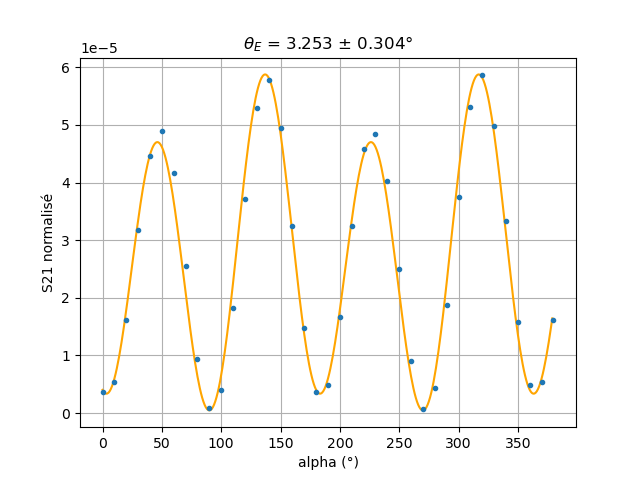

In [215]:
def cos2cos2(alpha, delta_theta, amp=1, offset1=0, offset2=0):
    return amp * (np.cos(np.radians(alpha))**2+ offset1) * (np.cos(np.radians(alpha + 90 - delta_theta))**2+ offset2)

# Sans donner d'erreur au fit
# Take the mean
t = 1

signal = mean_over_freqscans[:, t]

# Fit the data
popt, pcov = curve_fit(cos2cos2, alpha, signal, absolute_sigma=False)
error = np.sqrt(np.diag(pcov))

print("Paramètres optimisés :", popt)
print("Erreurs sur les paramètres :", error)

# Residus et chi2
residuals = signal - cos2cos2(alpha, *popt)
std_res = np.std(residuals)
print("Écart-type des résidus :", std_res)
chi2 = get_chi2(signal, cos2cos2(alpha, *popt), std_res)
print("Chi2 :", chi2)

chi2_red = chi2 / (len(alpha) - len(popt))
print("Chi2 réduit :", chi2_red)

plt.figure()
plt.errorbar(alpha, signal, marker='.', ls='None')
plt.plot(tt, cos2cos2(tt, *popt), 'orange', label='Fit cos^4')
plt.xlabel("alpha (°)")
plt.ylabel("S21 normalisé")
plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(popt[0], error[0]))
plt.grid(10)

# Residus 

On soustrait le modèle calculé sur la moyenne à chaque fréquence pour essayer d'identifier une systématique.

In [37]:
mag_lin.shape

(5, 39, 4, 60)

In [38]:
the_model = cos4(alpha, *popt)

In [39]:
residus_freq = mag_lin - the_model[None, :, None, None]
print(residus_freq.shape)

(5, 39, 4, 60)


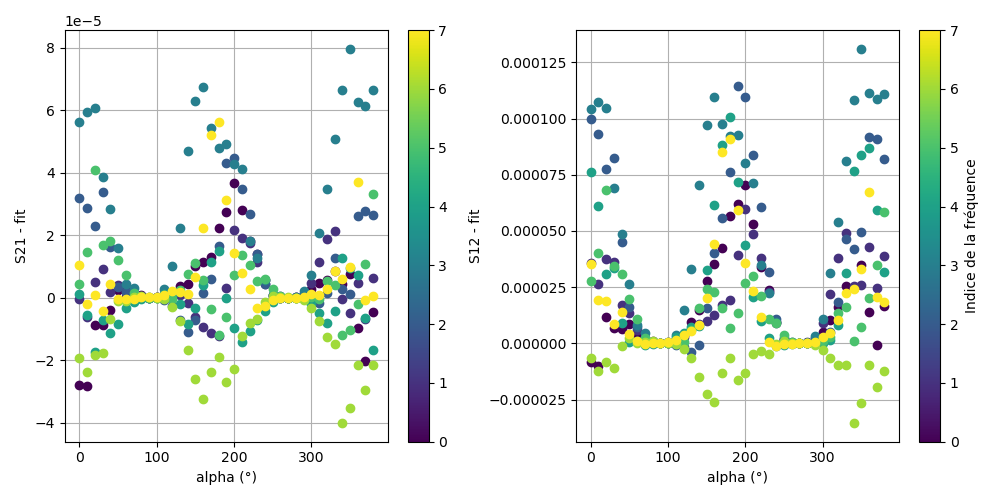

In [40]:
### Plot chaque fréquence
s = 0 # Scan

freqs = [0, 2, 3, 10, 15, 20, 30, 40]
nf = len(freqs)
tt = np.arange(0, 380)
colors, norm, cmap = get_colors(nf, cmap_name='viridis', vmin=0, vmax=nf-1)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax = ax.ravel()
for i, f in enumerate(freqs):
    ax[0].plot(alpha, residus_freq[s, :, 0, f], 'o', color=colors[i]) # S21
    ax[1].plot(alpha, residus_freq[s, :, 1, f], 'o', color=colors[i]) # S12

ax[0].set_xlabel("alpha (°)")
ax[0].set_ylabel("S21 - fit")
#ax[0].set_yscale('log')
ax[0].grid(10)

ax[1].set_xlabel("alpha (°)")
ax[1].set_ylabel("S12 - fit")
#ax[1].set_yscale('log')
ax[1].grid(10)
# créer une colorbar qui montre l'échelle d'indices (ou de valeurs réelles)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # nécessaire pour colorbar
cbar = plt.colorbar(sm, ax=ax[0])
cbar = plt.colorbar(sm, ax=ax[1])
cbar.set_label('Indice de la fréquence')

fig.tight_layout()

# TEST

Paramètres optimisés : [1.59152686e+00 2.19881111e-04 3.99247250e-06]
Erreurs sur les paramètres : [3.13228724e-01 5.26943959e-06 7.83225001e-07]
Écart-type des résidus : 4.019050979689394e-06
Chi2 : 77.00000000000001
Chi2 réduit : 1.0405405405405408


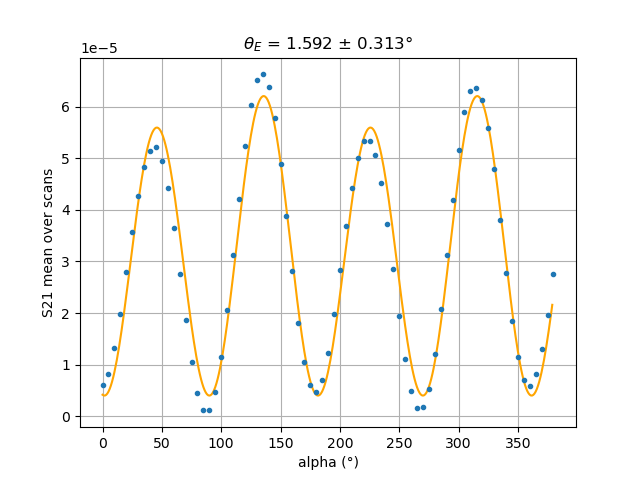

In [169]:
t = 0 # trace index (S21 or S12)

signal = np.mean(mag_lin[:, 1, :], axis=1) 
#sigma = std_over_scans[:, t, f] / np.sqrt(nscans)  # Erreur sur la moyenne

# Normalize to the max
#signal /= np.max(signal)

# Fit the data
popt, pcov = curve_fit(cos2cos2, alpha, signal, sigma=None, absolute_sigma=False)
error = np.sqrt(np.diag(pcov))

print("Paramètres optimisés :", popt)
print("Erreurs sur les paramètres :", error)

# Residus et chi2
residuals = signal - cos2cos2(alpha, *popt)
std_res = np.std(residuals)
print("Écart-type des résidus :", std_res)
chi2 = get_chi2(signal, cos2cos2(alpha, *popt), std_res)
print("Chi2 :", chi2)

chi2_red = chi2 / (len(alpha) - len(popt))
print("Chi2 réduit :", chi2_red)

fig = plt.figure()
plt.errorbar(alpha, signal, yerr=0, marker='.', ls='None')
plt.plot(tt, cos2cos2(tt, *popt), 'orange', label='Fit cos^4')
plt.xlabel("alpha (°)")
plt.ylabel("S21 mean over scans")
plt.title(r'$\theta_E$ = {:.3f} ± {:.3f}°'.format(popt[0], error[0]))
plt.grid(10)
#fig.savefig(f"../Plots/Scan_Fit_freq{f}.png", dpi=300)